# heatmap plot from casim data

In [1]:
from matplotlib.colors import PowerNorm
import matplotlib as mpl
import xarray as xr 
import pandas as pd
import numpy as np 
from glob import glob 
import matplotlib.pyplot as plt 
from scipy.special import gamma, gammainc
import re
import xesmf as xe
import os
import imageio
from matplotlib.lines import Line2D
import seaborn as sns


import sys
# needed so I can call the functions from another folder.
sys.path.append('/home/users/esree/shes_a_model/model_functions/')
# loads of homemade functions <3 <3
from casim_boring_functions import open_declan_nc, make_variable, slice_to_domain, mask_altitude, mask_non_cloud, kg_to_g


In [2]:
a_date = '20220730'
a_experiment = 'expt1'
max_time = 21
new_combined = open_declan_nc(a_date, a_experiment, max_time = max_time)
sliced_domain = slice_to_domain(new_combined)
sliced_domain = mask_altitude(sliced_domain)

## make new units for some hydrometeors
new_hydro_list = ['graupel', 'cloud', 'ice', 'snow', 'rain']
for hydro in new_hydro_list:
    sliced_domain = make_variable(sliced_domain, hydro)

for hydro in new_hydro_list:
    sliced_domain = make_variable(sliced_domain, hydro, 'mass')

t ='2022-07-30T18:00:00.000000000'
a_time = sliced_domain.sel(time=t)

## figure out values

In [8]:
t ='2022-07-30T18:00:00.000000000'
a_time = sliced_domain.sel(time=t)
a_time['air_temperature_c'] = a_time['air_temperature'] - 273.15
a_time['air_temperature_c'].min().values
a_time['air_temperature_c'].attrs["units"] = 'Celsius'
a_time

<xarray.Dataset> Size: 3MB
Dimensions:                                           (model_level_number: 70,
                                                       grid_latitude: 22,
                                                       grid_longitude: 14)
Coordinates:
  * model_level_number                                (model_level_number) int32 280B ...
  * grid_latitude                                     (grid_latitude) float32 88B ...
  * grid_longitude                                    (grid_longitude) float64 112B ...
    time                                              datetime64[ns] 8B 2022-...
    forecast_reference_time                           datetime64[ns] 8B ...
    forecast_period                                   timedelta64[ns] 8B ...
    level_height                                      (model_level_number) float32 280B dask.array<chunksize=(70,), meta=np.ndarray>
    sigma                                             (model_level_number) float32 280B dask.array<chunksize=(70,), meta=np.ndarray>
    lon                                               (grid_latitude, grid_longitude) float64 2kB dask.array<chunksize=(22, 14), meta=np.ndarray>
    lat                                               (grid_latitude, grid_longitude) float64 2kB dask.array<chunksize=(22, 14), meta=np.ndarray>
    true_level_height_asl                             (model_level_number, grid_latitude, grid_longitude) float32 86kB dask.array<chunksize=(70, 22, 14), meta=np.ndarray>
Data variables: (12/39)
    number_of_cloud_droplets_per_kg_of_air            (model_level_number, grid_latitude, grid_longitude) float32 86kB dask.array<chunksize=(35, 11, 5), meta=np.ndarray>
    number_of_rain_drops_per_kg_of_air                (model_level_number, grid_latitude, grid_longitude) float32 86kB dask.array<chunksize=(35, 11, 5), meta=np.ndarray>
    number_of_ice_particles_per_kg_of_air             (model_level_number, grid_latitude, grid_longitude) float32 86kB dask.array<chunksize=(35, 11, 5), meta=np.ndarray>
    number_of_snow_aggregates_per_kg_of_air           (model_level_number, grid_latitude, grid_longitude) float32 86kB dask.array<chunksize=(35, 11, 5), meta=np.ndarray>
    number_of_graupel_particles_per_kg_of_air         (model_level_number, grid_latitude, grid_longitude) float32 86kB dask.array<chunksize=(35, 11, 5), meta=np.ndarray>
    cloud_volume_fraction_in_atmosphere_layer         (model_level_number, grid_latitude, grid_longitude) float32 86kB dask.array<chunksize=(35, 11, 5), meta=np.ndarray>
    ...                                                ...
    ice_mass_L                                        (model_level_number, grid_latitude, grid_longitude) float32 86kB dask.array<chunksize=(35, 11, 5), meta=np.ndarray>
    snow_mass_m3                                      (model_level_number, grid_latitude, grid_longitude) float32 86kB dask.array<chunksize=(35, 11, 5), meta=np.ndarray>
    snow_mass_L                                       (model_level_number, grid_latitude, grid_longitude) float32 86kB dask.array<chunksize=(35, 11, 5), meta=np.ndarray>
    rain_mass_m3                                      (model_level_number, grid_latitude, grid_longitude) float32 86kB dask.array<chunksize=(35, 11, 5), meta=np.ndarray>
    rain_mass_L                                       (model_level_number, grid_latitude, grid_longitude) float32 86kB dask.array<chunksize=(35, 11, 5), meta=np.ndarray>
    air_temperature_c                                 (model_level_number, grid_latitude, grid_longitude) float32 86kB dask.array<chunksize=(35, 11, 5), meta=np.ndarray>
Attributes: (12/14)
    um_suite:          u-dd455@281404
    casim_branches:    https://code.metoffice.gov.uk/trac/monc/browser/casim/...
    um_branches:       https://code.metoffice.gov.uk/trac/um/browser/main/bra...
    creator_contact:   Declan Finney (d.l.finney@leeds.ac.uk), University of ...
    title:             Simulations over the southwest USA for the DCMEX campa...


## make gif of max value from domain

In [5]:
sliced_domain

<xarray.Dataset> Size: 167MB
Dimensions:                                           (time: 51,
                                                       model_level_number: 70,
                                                       grid_latitude: 22,
                                                       grid_longitude: 14)
Coordinates:
  * time                                              (time) datetime64[ns] 408B ...
  * model_level_number                                (model_level_number) int32 280B ...
  * grid_latitude                                     (grid_latitude) float32 88B ...
  * grid_longitude                                    (grid_longitude) float64 112B ...
    forecast_reference_time                           datetime64[ns] 8B ...
    forecast_period                                   timedelta64[ns] 8B ...
    level_height                                      (model_level_number) float32 280B dask.array<chunksize=(70,), meta=np.ndarray>
    sigma                                             (model_level_number) float32 280B dask.array<chunksize=(70,), meta=np.ndarray>
    lon                                               (grid_latitude, grid_longitude) float64 2kB dask.array<chunksize=(22, 14), meta=np.ndarray>
    lat                                               (grid_latitude, grid_longitude) float64 2kB dask.array<chunksize=(22, 14), meta=np.ndarray>
    true_level_height_asl                             (model_level_number, grid_latitude, grid_longitude) float32 86kB dask.array<chunksize=(70, 22, 14), meta=np.ndarray>
Data variables: (12/38)
    number_of_cloud_droplets_per_kg_of_air            (time, model_level_number, grid_latitude, grid_longitude) float32 4MB dask.array<chunksize=(2, 35, 11, 5), meta=np.ndarray>
    number_of_rain_drops_per_kg_of_air                (time, model_level_number, grid_latitude, grid_longitude) float32 4MB dask.array<chunksize=(2, 35, 11, 5), meta=np.ndarray>
    number_of_ice_particles_per_kg_of_air             (time, model_level_number, grid_latitude, grid_longitude) float32 4MB dask.array<chunksize=(2, 35, 11, 5), meta=np.ndarray>
    number_of_snow_aggregates_per_kg_of_air           (time, model_level_number, grid_latitude, grid_longitude) float32 4MB dask.array<chunksize=(2, 35, 11, 5), meta=np.ndarray>
    number_of_graupel_particles_per_kg_of_air         (time, model_level_number, grid_latitude, grid_longitude) float32 4MB dask.array<chunksize=(2, 35, 11, 5), meta=np.ndarray>
    cloud_volume_fraction_in_atmosphere_layer         (time, model_level_number, grid_latitude, grid_longitude) float32 4MB dask.array<chunksize=(2, 35, 11, 5), meta=np.ndarray>
    ...                                                ...
    ice_mass_m3                                       (time, model_level_number, grid_latitude, grid_longitude) float32 4MB dask.array<chunksize=(2, 35, 11, 5), meta=np.ndarray>
    ice_mass_L                                        (time, model_level_number, grid_latitude, grid_longitude) float32 4MB dask.array<chunksize=(2, 35, 11, 5), meta=np.ndarray>
    snow_mass_m3                                      (time, model_level_number, grid_latitude, grid_longitude) float32 4MB dask.array<chunksize=(2, 35, 11, 5), meta=np.ndarray>
    snow_mass_L                                       (time, model_level_number, grid_latitude, grid_longitude) float32 4MB dask.array<chunksize=(2, 35, 11, 5), meta=np.ndarray>
    rain_mass_m3                                      (time, model_level_number, grid_latitude, grid_longitude) float32 4MB dask.array<chunksize=(2, 35, 11, 5), meta=np.ndarray>
    rain_mass_L                                       (time, model_level_number, grid_latitude, grid_longitude) float32 4MB dask.array<chunksize=(2, 35, 11, 5), meta=np.ndarray>
Attributes: (12/14)
    um_suite:          u-dd455@281404
    casim_branches:    https://code.metoffice.gov.uk/trac/monc/browser/casim/...
    um_branches:       https://code.metoffice.gov.uk/trac/um/browser/main/br

### v1 of gif making

In [8]:
save_folder = '/home/users/esree/shes_a_model/dcmex_plotting/plot_saving/lat_lon_birdseye/'

delete_pngs = True

# make new folder if doesn't already exist
time_list = sliced_domain["time"].values
var_name = 'upward_air_velocity' #########################################################
var_units = 'm/s' #sliced_domain[var_name].units

specif_save_folder = f'{save_folder}{a_date}_{a_experiment}/{var_name}'
if not os.path.exists(specif_save_folder):
    os.makedirs(specif_save_folder)
saving_location = specif_save_folder+'/'

orography = sliced_domain["true_level_height_asl"].isel(model_level_number=0)

# then for each grid lat / lon, we choose the max height
max_height_lat = orography.max(dim="grid_latitude") # function of longitude
max_height_lon = orography.max(dim="grid_longitude") # fuction of latitude

## as lat and lon are 2D (bcos model grid lat lon is rotated)
## this is done to flatten out lat / lon dimensions
lon_1d = sliced_domain["lon"].mean(dim="grid_latitude") #(grid_longitude,)
lat_1d = sliced_domain["lat"].mean(dim="grid_longitude") #(grid_latitude,)

min_lat = 34.2
max_lat = 33.8
min_lon = -107.4
max_lon = -107.0

vmax_n = sliced_domain[var_name].max().values
vmin_n = sliced_domain[var_name].min().values
m_height_lim = 15000
colour_map = "coolwarm" #"Blues_r" 'coolwarm'


In [10]:
for t in time_list:
    a_time = sliced_domain.sel(time=t)
    save_name = f"{pd.to_datetime(str(t)).strftime('%y%m%d_%H%M%S')}_{var_name}"
    
    lat_max = a_time[var_name].max(dim="grid_latitude") # (model_level_number, grid_longitude)
    z_lat_max = a_time["true_level_height_asl"].max(dim="grid_latitude") # (model_level_number, grid_longitude)
    lon_max = a_time[var_name].max(dim="grid_longitude") # (model_level_number, grid_latitude)
    z_lon_max = a_time["true_level_height_asl"].max(dim="grid_longitude") # (model_level_number, grid_latitude)
    z_max = a_time[var_name].max(dim="model_level_number") # (grid_latitude, grid_longitude)

    z = lat_max.values 
    h = z_lat_max.values 
    lon = lon_1d.values

    """ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ plotting ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ """
    fig = plt.figure(figsize=(10, 8))

    # Create a 3x3 logical grid
    gs = fig.add_gridspec(3, 3)

    # Subplots with custom spans:
    ax1 = fig.add_subplot(gs[0, 0:2])   # top-left → 2 cols × 1 row
    ax2 = fig.add_subplot(gs[0, 2])     # top-right → 1 col × 1 row
    ax2.axis("off")
    ax3 = fig.add_subplot(gs[1:3, 0:2]) # bottom-left → 2 cols × 2 rows
    ax4 = fig.add_subplot(gs[1:3, 2])   # bottom-right → 1 col × 2 rows

    ax1.plot(lon_1d, max_height_lat, color="grey")
    ax1.set_xlim(min_lon, max_lon)

    # the pcm -> for making colourbar
    ax1.pcolormesh(
        lon_1d.values,
        z_lat_max.values,
        lat_max.values,
        shading="auto",
        cmap=colour_map,
        vmin=vmin_n, vmax=vmax_n)
    ax1.set_ylabel("alt (m)")
    ax1.set_ylim(0, m_height_lim)
    ax1.tick_params(axis="x", bottom=False, labelbottom=False) # turn off y-axis ticks and labels for ax4

    ax4.plot(max_height_lon, lat_1d, color="grey")
    ax4.set_ylim(max_lat, min_lat)
    ax4.pcolormesh(
        z_lon_max.T,
        lat_1d,
        lon_max.T,
        shading="auto",
        cmap=colour_map,
        vmin=vmin_n, vmax=vmax_n)
    ax4.set_xlabel("alt (m)")
    ax4.set_xlim(0, m_height_lim)
    ax4.tick_params(axis="y", left=False, labelleft=False) # turn off y-axis ticks and labels for ax4

    ax3.set_xlim(min_lon, max_lon)
    ax3.set_ylim(max_lat, min_lat)

    ax3.contour(
        sliced_domain["lon"].values,
        sliced_domain["lat"].values,
        orography.values,
        levels=[2250],   # only this contour
        colors="grey",
        linewidths=2)

    pcm = ax3.pcolormesh(
        a_time["lon"].values,
        a_time["lat"].values,
        z_max.values,
        shading="auto",
        cmap=colour_map,
        vmin=vmin_n, vmax=vmax_n)

    ax3.set_xlabel("Longitude")
    ax3.set_ylabel("Latitude")

    ### add colourbar

    cbar = fig.colorbar(
        pcm,
        ax=[ax1, ax3, ax4],
        orientation="vertical",
        location="left",
        pad=-0.0001,
        fraction=0.03)
    cbar.set_label(f"max {var_name} ({var_units})")

    ## set time 
    time_name = pd.to_datetime(str(t)).strftime("%H:%M:%S")
    title_str = f'{var_name} \n {time_name} UTC'

    ax2.set_title(title_str, loc="center", y=0.5, fontsize=16)

    plt.tight_layout()
    plt.savefig(saving_location+save_name, bbox_inches='tight')
    plt.close()

## make gif
image_list = glob(os.path.join(saving_location, '*.png'))
image_list.sort()
frames = []
for i in range(len(image_list)):
    image = imageio.v2.imread(image_list[i])
    frames.append(image)

imageio.mimsave(saving_location+f'{a_date}_{a_experiment}_{var_name}.gif', frames, fps=5)
if delete_pngs:
    for image in image_list:
        os.remove(image)


/tmp/ipykernel_2157259/3909055052.py:95: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_2157259/3909055052.py:95: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_2157259/3909055052.py:95: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_2157259/3909055052.py:95: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_2157259/3909055052.py:95: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_2157259/3909055052.py:95: UserWarning: This figure includes Axes that are not compatible with tight_layout, so

## w contour in plots
where are highest updrafts?
<br>
plotting w and graupel conc? somehow together
<br>
melting level? / alt?

In [4]:
t ='2022-07-30T18:00:00.000000000'
a_time = sliced_domain.sel(time=t)
a_time


<xarray.Dataset> Size: 3MB
Dimensions:                                           (model_level_number: 70,
                                                       grid_latitude: 22,
                                                       grid_longitude: 14)
Coordinates:
  * model_level_number                                (model_level_number) int32 280B ...
  * grid_latitude                                     (grid_latitude) float32 88B ...
  * grid_longitude                                    (grid_longitude) float64 112B ...
    time                                              datetime64[ns] 8B 2022-...
    forecast_reference_time                           datetime64[ns] 8B ...
    forecast_period                                   timedelta64[ns] 8B ...
    level_height                                      (model_level_number) float32 280B dask.array<chunksize=(70,), meta=np.ndarray>
    sigma                                             (model_level_number) float32 280B dask.array<chunksize=(70,), meta=np.ndarray>
    lon                                               (grid_latitude, grid_longitude) float64 2kB dask.array<chunksize=(22, 14), meta=np.ndarray>
    lat                                               (grid_latitude, grid_longitude) float64 2kB dask.array<chunksize=(22, 14), meta=np.ndarray>
    true_level_height_asl                             (model_level_number, grid_latitude, grid_longitude) float32 86kB dask.array<chunksize=(70, 22, 14), meta=np.ndarray>
Data variables: (12/38)
    number_of_cloud_droplets_per_kg_of_air            (model_level_number, grid_latitude, grid_longitude) float32 86kB dask.array<chunksize=(35, 11, 5), meta=np.ndarray>
    number_of_rain_drops_per_kg_of_air                (model_level_number, grid_latitude, grid_longitude) float32 86kB dask.array<chunksize=(35, 11, 5), meta=np.ndarray>
    number_of_ice_particles_per_kg_of_air             (model_level_number, grid_latitude, grid_longitude) float32 86kB dask.array<chunksize=(35, 11, 5), meta=np.ndarray>
    number_of_snow_aggregates_per_kg_of_air           (model_level_number, grid_latitude, grid_longitude) float32 86kB dask.array<chunksize=(35, 11, 5), meta=np.ndarray>
    number_of_graupel_particles_per_kg_of_air         (model_level_number, grid_latitude, grid_longitude) float32 86kB dask.array<chunksize=(35, 11, 5), meta=np.ndarray>
    cloud_volume_fraction_in_atmosphere_layer         (model_level_number, grid_latitude, grid_longitude) float32 86kB dask.array<chunksize=(35, 11, 5), meta=np.ndarray>
    ...                                                ...
    ice_mass_m3                                       (model_level_number, grid_latitude, grid_longitude) float32 86kB dask.array<chunksize=(35, 11, 5), meta=np.ndarray>
    ice_mass_L                                        (model_level_number, grid_latitude, grid_longitude) float32 86kB dask.array<chunksize=(35, 11, 5), meta=np.ndarray>
    snow_mass_m3                                      (model_level_number, grid_latitude, grid_longitude) float32 86kB dask.array<chunksize=(35, 11, 5), meta=np.ndarray>
    snow_mass_L                                       (model_level_number, grid_latitude, grid_longitude) float32 86kB dask.array<chunksize=(35, 11, 5), meta=np.ndarray>
    rain_mass_m3                                      (model_level_number, grid_latitude, grid_longitude) float32 86kB dask.array<chunksize=(35, 11, 5), meta=np.ndarray>
    rain_mass_L                                       (model_level_number, grid_latitude, grid_longitude) float32 86kB dask.array<chunksize=(35, 11, 5), meta=np.ndarray>
Attributes: (12/14)
    um_suite:          u-dd455@281404
    casim_branches:    https://code.metoffice.gov.uk/trac/monc/browser/casim/...
    um_branches:       https://code.metoffice.gov.uk/trac/um/browser/main/bra...
    creator_contact:   Declan Finney (d.l.finney@leeds.ac.uk), University of ...
    title:             Simulations over the southwest USA for the DCMEX campa...


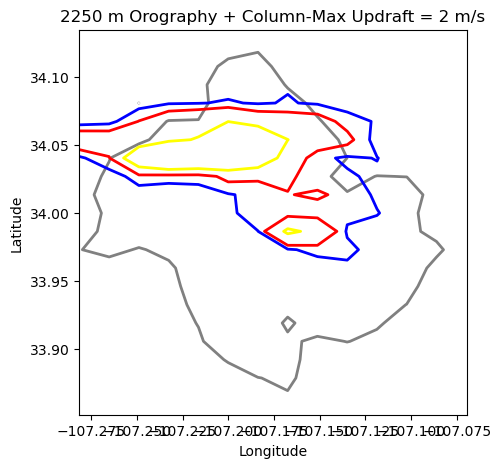

In [6]:
fig = plt.figure(figsize=(5, 5))
ax1 = fig.add_subplot(111)   # top-left → 2 cols × 1 row
lon_1d = a_time["lon"].mean(dim="grid_latitude") #(grid_longitude,)
lat_1d = a_time["lat"].mean(dim="grid_longitude") #(grid_latitude,)

orography = a_time["true_level_height_asl"].isel(model_level_number=0)
max_height_lat = orography.max(dim="grid_latitude") # function of longitude
max_height_lon = orography.max(dim="grid_longitude") # fuction of latitude

ax1.contour(
    sliced_domain["lon"].values,
    sliced_domain["lat"].values,
    orography.values,
    levels=[2250],   # only this contour
    colors="grey",
    linewidths=2)

updraft = a_time['upward_air_velocity']
w_max = updraft.max(dim="model_level_number")


# Add contour where updraft = 2 m/s
ax1.contour(
    w_max["lon"].values,
    w_max["lat"].values,
    w_max.values,
    levels=[2],
    colors="red",
    linewidths=2)

ax1.contour(
    w_max["lon"].values,
    w_max["lat"].values,
    w_max.values,
    levels=[1],
    colors="blue",
    linewidths=2,
)
ax1.contour(
    w_max["lon"].values,
    w_max["lat"].values,
    w_max.values,
    levels=[5],
    colors="yellow",
    linewidths=2,
)

ax1.set_xlabel("Longitude")
ax1.set_ylabel("Latitude")
ax1.set_title("2250 m Orography + Column-Max Updraft = 2 m/s")
plt.show()

(0.0, 15000.0)

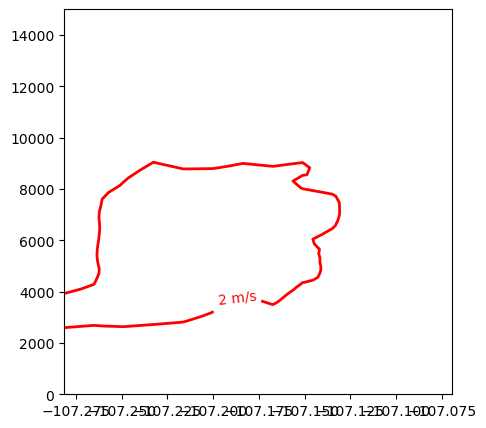

In [34]:
# Example: take max over latitude for each height/lon
w_cross = a_time["upward_air_velocity"].max(dim="grid_latitude")

# Corresponding height field
z_cross = a_time["true_level_height_asl"].max(dim="grid_latitude")

fig = plt.figure(figsize=(5, 5))
ax1 = fig.add_subplot(111)   # top-left → 2 cols × 1 row

# Make longitude 2D for contour()
X_lon = np.tile(
    lon_1d.values,
    (w_cross.shape[0], 1)
)

cs = ax1.contour(
    X_lon,
    z_cross.values,
    w_cross.values,
    levels=[2],
    colors="red",
    linewidths=2,
)

ax1.clabel(cs, fmt="2 m/s")
ax1.set_ylim(0, max_alt)

### v2 of gif making - with function!

In [71]:
def easy_plotting_lat_lon_map(a_time_step, 
                              variable_name = 'orography', 
                              colourmesh_contour = 'colourmesh',
                              contour_level = [2250],
                              a_vmax = None,
                              a_vmin = None,
                              max_alt = 15000,
                              specific_colourmap = None):
    ### this needs to be placed after the defined plot, just kind of slots into place
    ## can layer up plots

    """
    easy stacking plotting function for lat / lon maps, can overlay different things?

    Args:
        a_time_step (xarray dataset): a single time step of the model output, soelected using .sel(time=...)
        variable_name (str, optional): the variable you want to plot. Defaults to 'orography'.
        colourmesh_contour (str, optional): whether you want to plot the variable as a colourmesh or a contour. Defaults to 'colourmesh'.
        contour_level (list, optional): if plotting as a contour, the level(s) to plot. Defaults to [2250].
        vmax (float, optional): max value for colourmesh. Defaults to None.
        vmin (float, optional): min value for colourmesh. Defaults to None.
        var_units (str, optional): units of the variable being plotted, for colourbar labelling. Defaults to None.
        max_alt (int, optional): max altitude to plot. Defaults to 15000.
        specific_colourmap (str, optional): colourmap to use for colourmesh. Defaults to None, which will use the default colourmap.
    """

    min_lat = 34.2
    max_lat = 33.8
    min_lon = -107.4
    max_lon = -107.0

    # then for each grid lat / lon, we choose the max height
    lon_1d = a_time_step["lon"].mean(dim="grid_latitude") #(grid_longitude,)
    lat_1d = a_time_step["lat"].mean(dim="grid_longitude") #(grid_latitude,)

    if variable_name == 'orography':
        orography = a_time_step["true_level_height_asl"].isel(model_level_number=0)
        max_height_lat = orography.max(dim="grid_latitude") # function of longitude
        max_height_lon = orography.max(dim="grid_longitude") # fuction of latitude
        ax1.plot(lon_1d, max_height_lat, color="grey")
        ax4.plot(max_height_lon, lat_1d, color="grey")
        ax3.contour(
            a_time_step["lon"].values,
            a_time_step["lat"].values,
            orography.values,
            levels=contour_level,   # only this level
            colors="grey",
            linewidths=2)
    
    elif variable_name != 'orography': 
        lat_max = a_time_step[variable_name].max(dim="grid_latitude") # (model_level_number, grid_longitude)
        z_lat_max = a_time_step["true_level_height_asl"].max(dim="grid_latitude") # (model_level_number, grid_longitude)
        lon_max = a_time_step[variable_name].max(dim="grid_longitude") # (model_level_number, grid_latitude)
        z_lon_max = a_time_step["true_level_height_asl"].max(dim="grid_longitude") # (model_level_number, grid_latitude)
        z_max = a_time_step[variable_name].max(dim="model_level_number") # (grid_latitude, grid_longitude)
        
        lon_2d = np.tile(lon_1d.values,(lat_max.shape[0], 1))
        lat_2d = np.tile(lat_1d.values,(lon_max.shape[0], 1)).T

        if variable_name == 'upward_air_velocity':
            var_units = 'm/s'
        else:
            var_units = a_time_step[variable_name].units

        
        if colourmesh_contour == 'colourmesh':
            if specific_colourmap is None:
                specific_colourmap = ['Blues_r']

            ax1.pcolormesh(
                lon_1d.values,
                z_lat_max.values,
                lat_max.values,
                shading="auto",
                cmap=specific_colourmap[0],
                vmin=a_vmin, vmax=a_vmax)
            
            pcm = ax3.pcolormesh(
                a_time_step["lon"].values,
                a_time_step["lat"].values,
                z_max.values,
                shading="auto",
                cmap=specific_colourmap[0],
                vmin=a_vmin, vmax=a_vmax)
            
            ax4.pcolormesh(
                z_lon_max.T,
                lat_1d,
                lon_max.T,
                shading="auto",
                cmap=specific_colourmap[0],
                vmin=a_vmin, vmax=a_vmax)
            
            cbar = fig.colorbar(
                pcm,
                ax=[ax1, ax3, ax4],
                orientation="vertical",
                location="left",
                pad=-0.0001,
                fraction=0.03)

            cbar.set_label(f"max {variable_name} ({var_units})")

        
        elif colourmesh_contour != 'colourmesh':
            number_of_contours = len(contour_level)
            # contour plot
            if specific_colourmap is None or len(specific_colourmap) < number_of_contours:
                specific_colourmap = ['red', 'yellow', 'blue', 'green', 'orange']
            legend_lines = []

            for i in range(len(contour_level)):
                a_contour_level = contour_level[i]
                a_colour = specific_colourmap[i]
            
                ax1.contour(
                    lon_2d,
                    z_lat_max.values,
                    lat_max.values,
                    levels=[a_contour_level],
                    colors=a_colour,
                    linewidths=2,)

                # so get ledgend
                ax3.contour(
                    z_max["lon"].values,
                    z_max["lat"].values,
                    z_max.values,
                    levels=[a_contour_level],
                    colors=a_colour,
                    linewidths=2)
            
                ax4.contour(
                    z_lon_max.T,
                    lat_2d,
                    lon_max.T,
                    levels=[a_contour_level],
                    colors=a_colour,
                    linewidths=2)
            
                legend_lines.append(Line2D(
                    [0], [0],
                    color=a_colour,
                    lw=2,
                    label=f"{variable_name} = {a_contour_level} {var_units}"))
            
            ax2.legend(handles=legend_lines, loc= "lower center")
            
    
    ax1.set_ylabel("alt (m)")
    ax1.set_ylim(0, max_alt)
    ax1.set_xlim(min_lon, max_lon)
    ax1.tick_params(axis="x", bottom=False, labelbottom=False) # turn off x-axis ticks and labels for ax1

    ax3.set_xlim(min_lon, max_lon)
    ax3.set_ylim(max_lat, min_lat)
    ax3.set_xlabel("Longitude")
    ax3.set_ylabel("Latitude")

    ax4.set_xlabel("alt (m)")
    ax4.set_xlim(0, max_alt)
    ax4.set_ylim(max_lat, min_lat)
    ax4.tick_params(axis="y", left=False, labelleft=False) # turn off y-axis ticks and labels for ax4


In [4]:
save_folder = '/home/users/esree/shes_a_model/dcmex_plotting/plot_saving/lat_lon_birdseye/'

delete_pngs = True

# make new folder if doesn't already exist
time_list = sliced_domain["time"].values
var_name = 'upward_air_velocity' #########################################################


vmax_n = sliced_domain[var_name].max().values
vmin_n = sliced_domain[var_name].min().values
m_height_lim = 15000
colour_map = "Blues_r" #"Blues_r" 'coolwarm'


a_time = sliced_domain.sel(time=t)
save_name = f"{pd.to_datetime(str(t)).strftime('%y%m%d_%H%M%S')}_{var_name}"

lat_max = a_time[var_name].max(dim="grid_latitude") # (model_level_number, grid_longitude)
z_lat_max = a_time["true_level_height_asl"].max(dim="grid_latitude") # (model_level_number, grid_longitude)
lon_max = a_time[var_name].max(dim="grid_longitude") # (model_level_number, grid_latitude)
z_lon_max = a_time["true_level_height_asl"].max(dim="grid_longitude") # (model_level_number, grid_latitude)
z_max = a_time[var_name].max(dim="model_level_number") # (grid_latitude, grid_longitude)

z = lat_max.values 
h = z_lat_max.values 
lon = lon_1d.values

""" ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ plotting ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ """
fig = plt.figure(figsize=(10, 8))

# Create a 3x3 logical grid
gs = fig.add_gridspec(3, 3)

# Subplots with custom spans:
ax1 = fig.add_subplot(gs[0, 0:2])   # top-left → 2 cols × 1 row
ax2 = fig.add_subplot(gs[0, 2])     # top-right → 1 col × 1 row
ax2.axis("off")
ax3 = fig.add_subplot(gs[1:3, 0:2]) # bottom-left → 2 cols × 2 rows
ax4 = fig.add_subplot(gs[1:3, 2])   # bottom-right → 1 col × 2 rows

easy_plotting_lat_lon_map(a_time)
easy_plotting_lat_lon_map(a_time, variable_name=var_name, a_vmin=vmin_n, a_vmax=vmax_n, specific_colourmap=['coolwarm'])
easy_plotting_lat_lon_map(a_time, variable_name=var_name, colourmesh_contour='contour', contour_level= [5, 2] , specific_colourmap=['red', 'yellow'])

## set time 
time_name = pd.to_datetime(str(t)).strftime("%H:%M:%S")
title_str = f'{var_name} \n {time_name} UTC'

ax2.set_title(title_str, loc="center", y=0.5, fontsize=16)

plt.tight_layout()





KeyboardInterrupt: 

### blerg scatter

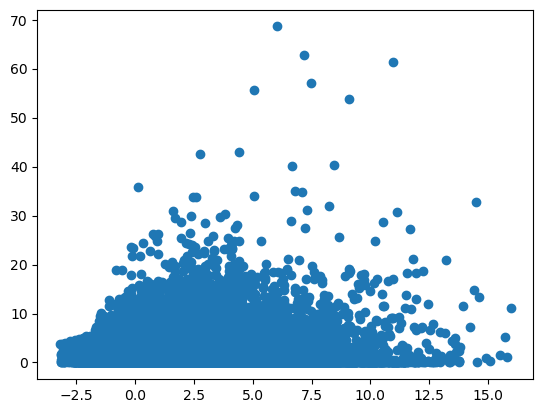

In [14]:
plt.scatter(sliced_domain['upward_air_velocity'], sliced_domain['graupel_number_L'])

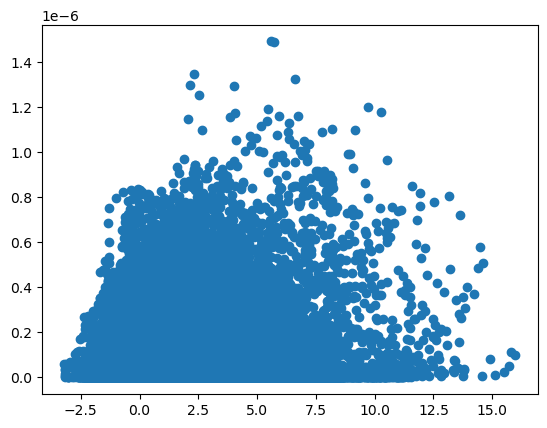

In [15]:
#plt.scatter(a_time['upward_air_velocity'], a_time['graupel_number_L'])

plt.scatter(sliced_domain['upward_air_velocity'], sliced_domain['graupel_mass_L'])

Text(0, 0.5, 'graupel mass conc (kg/L)')

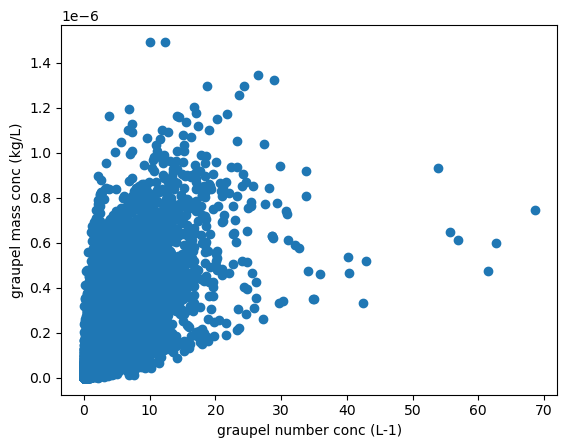

In [16]:
plt.scatter(sliced_domain['graupel_number_L'], sliced_domain['graupel_mass_L'])
plt.xlabel('graupel number conc (L-1)')
plt.ylabel('graupel mass conc (kg/L)')

## v2 py code heatmap

In [3]:
a_date = '20220730'
a_experiment = 'expt1'
max_time = 21
max_altitude = 15000
new_combined = open_declan_nc(a_date, a_experiment, max_time = max_time)
sliced_domain = slice_to_domain(new_combined)
sliced_domain = mask_altitude(sliced_domain, max_altitude=max_altitude)
sliced_domain = mask_non_cloud(sliced_domain) # only fully cloudy boxes will be considered

## make new units for some hydrometeors
new_hydro_list = ['graupel', 'cloud', 'ice', 'snow', 'rain']
for hydro in new_hydro_list:
    sliced_domain = make_variable(sliced_domain, hydro)
    sliced_domain = make_variable(sliced_domain, hydro, 'mass')
    sliced_domain = kg_to_g(sliced_domain, hydro)


#for hydro in new_hydro_list:

t ='2022-07-30T18:00:00.000000000'
a_time = sliced_domain.sel(time=t)

## also make temperature - ºC
sliced_domain['air_temperature_c'] = sliced_domain['air_temperature'] - 273.15
sliced_domain['air_temperature_c'].attrs["units"] = 'Celsius'

sliced_domain['graupel_mass_ug_L'] = sliced_domain['graupel_mass_L'] * 1e9
sliced_domain['graupel_mass_ug_L'].attrs["units"] = 'µg L-1'

sliced_domain['graupel_number_mass'] = sliced_domain['graupel_number_L'] / sliced_domain['graupel_mass_ug_L']
sliced_domain['graupel_number_mass'].attrs["units"] = 'number µg-1'

sliced_domain["cloud_droplets_number_cc"] = sliced_domain["cloud_number_m3"] * 1e-6
sliced_domain["cloud_droplets_number_cc"].attrs["units"] = "cm-3"
sliced_domain["cloud_droplets_number_cc"].attrs["long_name"] = "Cloud droplets number concentration (cm-3)"

# this has been used in declans paper (https://acp.copernicus.org/articles/25/10907/2025/)- not sure if he included rain?
sliced_domain["total_cloud_mass"] = sliced_domain["mass_fraction_of_cloud_ice_in_air"] + sliced_domain["mass_fraction_of_cloud_ice_crystals_in_air"] + sliced_domain["mass_fraction_of_cloud_liquid_water_in_air"] + sliced_domain["mass_fraction_of_graupel_in_air"]
sliced_domain["total_cloud_mass"].attrs["units"] = "kg kg-1"

#sliced_domain['graupel_number_mass'] = sliced_domain['graupel_number_L'] / sliced_domain['graupel_mass_L']
#sliced_domain['graupel_number_mass'].attrs["units"] = 'number kg-1'


#non_negative_number_mass = sliced_domain['graupel_number_mass'] > 0
#sliced_domain_2 = sliced_domain.where(non_negative_number_mass)
sliced_domain_2 = sliced_domain.copy()
sliced_domain_2['graupel_number_mass'] = (sliced_domain['graupel_number_mass']
.where(np.isfinite(sliced_domain['graupel_number_mass'])))


num = sliced_domain['graupel_number_L']
mass = sliced_domain['graupel_mass_ug_L']
ratio = xr.where(mass > 0, num / mass, np.nan)

ratio = ratio.where(np.isfinite(ratio))

sliced_domain['graupel_number_mass_2'] = ratio
sliced_domain['graupel_number_mass_2'].attrs["units"] = 'number µg-1'


In [4]:
sliced_domain

<xarray.Dataset> Size: 152MB
Dimensions:                                           (time: 36,
                                                       model_level_number: 70,
                                                       grid_latitude: 22,
                                                       grid_longitude: 14)
Coordinates:
  * time                                              (time) datetime64[ns] 288B ...
  * model_level_number                                (model_level_number) int32 280B ...
  * grid_latitude                                     (grid_latitude) float32 88B ...
  * grid_longitude                                    (grid_longitude) float64 112B ...
    forecast_reference_time                           datetime64[ns] 8B 2022-...
    forecast_period                                   timedelta64[ns] 8B 00:0...
    level_height                                      (model_level_number) float32 280B dask.array<chunksize=(70,), meta=np.ndarray>
    sigma                                             (model_level_number) float32 280B dask.array<chunksize=(70,), meta=np.ndarray>
    lon                                               (grid_latitude, grid_longitude) float64 2kB dask.array<chunksize=(22, 14), meta=np.ndarray>
    lat                                               (grid_latitude, grid_longitude) float64 2kB dask.array<chunksize=(22, 14), meta=np.ndarray>
    true_level_height_asl                             (model_level_number, grid_latitude, grid_longitude) float32 86kB dask.array<chunksize=(70, 22, 14), meta=np.ndarray>
Data variables: (12/49)
    number_of_cloud_droplets_per_kg_of_air            (time, model_level_number, grid_latitude, grid_longitude) float32 3MB dask.array<chunksize=(2, 35, 11, 5), meta=np.ndarray>
    number_of_rain_drops_per_kg_of_air                (time, model_level_number, grid_latitude, grid_longitude) float32 3MB dask.array<chunksize=(2, 35, 11, 5), meta=np.ndarray>
    number_of_ice_particles_per_kg_of_air             (time, model_level_number, grid_latitude, grid_longitude) float32 3MB dask.array<chunksize=(2, 35, 11, 5), meta=np.ndarray>
    number_of_snow_aggregates_per_kg_of_air           (time, model_level_number, grid_latitude, grid_longitude) float32 3MB dask.array<chunksize=(2, 35, 11, 5), meta=np.ndarray>
    number_of_graupel_particles_per_kg_of_air         (time, model_level_number, grid_latitude, grid_longitude) float32 3MB dask.array<chunksize=(2, 35, 11, 5), meta=np.ndarray>
    cloud_volume_fraction_in_atmosphere_layer         (time, model_level_number, grid_latitude, grid_longitude) float32 3MB dask.array<chunksize=(2, 35, 11, 5), meta=np.ndarray>
    ...                                                ...
    air_temperature_c                                 (time, model_level_number, grid_latitude, grid_longitude) float32 3MB dask.array<chunksize=(2, 35, 11, 5), meta=np.ndarray>
    graupel_mass_ug_L                                 (time, model_level_number, grid_latitude, grid_longitude) float32 3MB dask.array<chunksize=(2, 35, 11, 5), meta=np.ndarray>
    graupel_number_mass                               (time, model_level_number, grid_latitude, grid_longitude) float32 3MB dask.array<chunksize=(2, 35, 11, 5), meta=np.ndarray>
    cloud_droplets_number_cc                          (time, model_level_number, grid_latitude, grid_longitude) float32 3MB dask.array<chunksize=(2, 35, 11, 5), meta=np.ndarray>
    total_cloud_mass                                  (time, model_level_number, grid_latitude, grid_longitude) float32 3MB dask.array<chunksize=(2, 35, 11, 5), meta=np.ndarray>
    graupel_number_mass_2                             (time, model_level_number, grid_latitude, grid_longitude) float32 3MB dask.array<chunksize=(2, 35, 11, 5), meta=np.ndarray>
Attributes: (12/14)
    um_suite:          u-dd455@281404
    casim_branches:    https://code.metoffice.gov.uk/trac/monc/browser/casim/...
    um_branches:       https://code.metoffice.gov.uk/trac/um/browse

In [4]:
sliced_domain['graupel_number_L'].max().values

array(68.61203, dtype=float32)

In [30]:
mass_values = sliced_domain['graupel_mass_L'] * 1e9
sliced_domain['graupel_mass_ug_L'] = mass_values.where(np.isfinite(mass_values)) # remove inf and nan
sliced_domain['graupel_mass_ug_L'].attrs["units"] = 'µg L-1'

# need to make sure number is also finite
number_values = sliced_domain['graupel_number_L']
sliced_domain['graupel_number_L'] = number_values.where(np.isfinite(number_values))

## if we normalise number and mass??? will that make a normal plot?
sliced_domain['graupel_mass_normalised'] = sliced_domain['graupel_mass_ug_L'] / sliced_domain['graupel_mass_ug_L'].max().values
sliced_domain['graupel_mass_normalised'].attrs["units"] = 'normalised mass'
sliced_domain['graupel_number_normalised'] = sliced_domain['graupel_number_L'] / sliced_domain['graupel_number_L'].max().values
sliced_domain['graupel_number_normalised'].attrs["units"] = 'normalised number'

'''
num = sliced_domain['graupel_number_L']
mass = sliced_domain['graupel_mass_ug_L']
ratio = xr.where((mass > 0) & (num > 0), num / mass, np.nan) # both number and mass need to be > 0 to get a value (idk if can have one without other fundamentally, but its causing issues)
ratio = ratio.where(np.isfinite(ratio))
'''
ratio = sliced_domain['graupel_number_normalised'] / sliced_domain['graupel_mass_normalised']
sliced_domain['graupel_number_mass'] = ratio
sliced_domain['graupel_number_mass'].attrs["units"] = 'ratio normalised number to normalised mass'


In [6]:
flat_mass = sliced_domain['graupel_mass_ug_L'].values.flatten()
flat_number = sliced_domain['graupel_number_L'].values.flatten()




In [7]:
sliced_domain['graupel_mass_ug_L'].max().values

array(1492.4452, dtype=float32)

<>:11: SyntaxWarning: invalid escape sequence '\d'
<>:11: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_3158738/4091425664.py:11: SyntaxWarning: invalid escape sequence '\d'
  plt.xlabel('CP$^{\dag}$')


Text(0.5, 0, 'CP$^{\\dag}$')

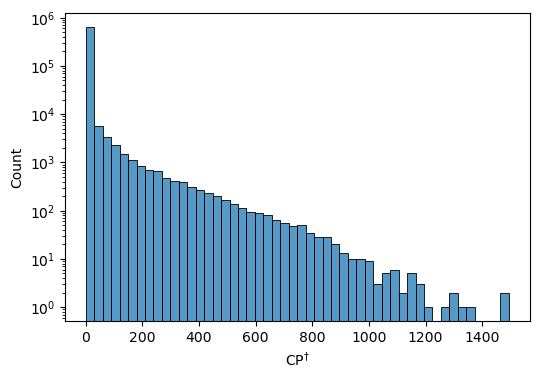

In [11]:
flat_mass_non_nan = flat_mass[np.isfinite(flat_mass)]


#flat = flat_mass.stack(points=da.dims).dropna("points")

plt.figure(figsize=(6, 4))
#sns.boxplot(y=flat_mass_non_nan)
sns.histplot(flat_mass_non_nan, bins=50)#, kde=True)
plt.yscale('log')
#plt.xlabel('graupel mass concentration (µg L-1)')
plt.xlabel('CP$^{\dag}$')

In [ ]:
top_1_percent_mass = sliced_domain['graupel_mass_ug_L'].quantile(0.999)
print(top_1_percent_mass.values)
top_1_percent_number = sliced_domain['graupel_number_L'].quantile(0.999)
print(top_1_percent_number.values)

570.682286254884


In [25]:
normal_mass_flat = sliced_domain['graupel_mass_normalised'].values.flatten()

In [26]:
normal_mass_flat

array([ 0.,  0.,  0., ..., nan, nan, nan], shape=(776160,), dtype=float32)

In [95]:
sliced_domain

<xarray.Dataset> Size: 137MB
Dimensions:                                           (time: 36,
                                                       model_level_number: 70,
                                                       grid_latitude: 22,
                                                       grid_longitude: 14)
Coordinates:
  * time                                              (time) datetime64[ns] 288B ...
  * model_level_number                                (model_level_number) int32 280B ...
  * grid_latitude                                     (grid_latitude) float32 88B ...
  * grid_longitude                                    (grid_longitude) float64 112B ...
    forecast_reference_time                           datetime64[ns] 8B 2022-...
    forecast_period                                   timedelta64[ns] 8B 00:0...
    level_height                                      (model_level_number) float32 280B dask.array<chunksize=(70,), meta=np.ndarray>
    sigma                                             (model_level_number) float32 280B dask.array<chunksize=(70,), meta=np.ndarray>
    lon                                               (grid_latitude, grid_longitude) float64 2kB dask.array<chunksize=(22, 14), meta=np.ndarray>
    lat                                               (grid_latitude, grid_longitude) float64 2kB dask.array<chunksize=(22, 14), meta=np.ndarray>
    true_level_height_asl                             (model_level_number, grid_latitude, grid_longitude) float32 86kB dask.array<chunksize=(70, 22, 14), meta=np.ndarray>
Data variables: (12/44)
    number_of_cloud_droplets_per_kg_of_air            (time, model_level_number, grid_latitude, grid_longitude) float32 3MB dask.array<chunksize=(2, 35, 11, 5), meta=np.ndarray>
    number_of_rain_drops_per_kg_of_air                (time, model_level_number, grid_latitude, grid_longitude) float32 3MB dask.array<chunksize=(2, 35, 11, 5), meta=np.ndarray>
    number_of_ice_particles_per_kg_of_air             (time, model_level_number, grid_latitude, grid_longitude) float32 3MB dask.array<chunksize=(2, 35, 11, 5), meta=np.ndarray>
    number_of_snow_aggregates_per_kg_of_air           (time, model_level_number, grid_latitude, grid_longitude) float32 3MB dask.array<chunksize=(2, 35, 11, 5), meta=np.ndarray>
    number_of_graupel_particles_per_kg_of_air         (time, model_level_number, grid_latitude, grid_longitude) float32 3MB dask.array<chunksize=(2, 35, 11, 5), meta=np.ndarray>
    cloud_volume_fraction_in_atmosphere_layer         (time, model_level_number, grid_latitude, grid_longitude) float32 3MB dask.array<chunksize=(2, 35, 11, 5), meta=np.ndarray>
    ...                                                ...
    air_temperature_c                                 (time, model_level_number, grid_latitude, grid_longitude) float32 3MB dask.array<chunksize=(2, 35, 11, 5), meta=np.ndarray>
    graupel_mass_ug_L                                 (time, model_level_number, grid_latitude, grid_longitude) float32 3MB dask.array<chunksize=(2, 35, 11, 5), meta=np.ndarray>
    graupel_number_mass                               (time, model_level_number, grid_latitude, grid_longitude) float32 3MB dask.array<chunksize=(2, 35, 11, 5), meta=np.ndarray>
    cloud_droplets_number_cc                          (time, model_level_number, grid_latitude, grid_longitude) float32 3MB dask.array<chunksize=(2, 35, 11, 5), meta=np.ndarray>
    total_cloud_mass                                  (time, model_level_number, grid_latitude, grid_longitude) float32 3MB dask.array<chunksize=(2, 35, 11, 5), meta=np.ndarray>
    graupel_number_mass_2                             (time, model_level_number, grid_latitude, grid_longitude) float32 3MB dask.array<chunksize=(2, 35, 11, 5), meta=np.ndarray>
Attributes: (12/14)
    um_suite:          u-dd455@281404
    casim_branches:    https://code.metoffice.gov.uk/trac/monc/browser/casim/...
    um_branches:       https://code.metoffice.gov.uk/trac/um/browse

In [91]:
#mass = sliced_domain['graupel_number_L']
mass = sliced_domain['graupel_number_mass']

print(mass.where(mass > 0).max().values)


/home/users/esree/miniforge3/envs/vs_code_envi/lib/python3.13/site-packages/dask/_task_spec.py:759: RuntimeWarning: divide by zero encountered in divide
  return self.func(*new_argspec)
/home/users/esree/miniforge3/envs/vs_code_envi/lib/python3.13/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/home/users/esree/miniforge3/envs/vs_code_envi/lib/python3.13/site-packages/dask/_task_spec.py:759: RuntimeWarning: divide by zero encountered in divide
  return self.func(*new_argspec)
/home/users/esree/miniforge3/envs/vs_code_envi/lib/python3.13/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/home/users/esree/miniforge3/envs/vs_code_envi/lib/python3.13/site-packages/dask/_task_spec.py:759: RuntimeWarning: divide by zero encountered in divide
  return self.func(*new_argspec)
/home/users/esree/miniforge3/envs/vs_code_envi/lib/python3.13/site-packa

inf


/home/users/esree/miniforge3/envs/vs_code_envi/lib/python3.13/site-packages/dask/_task_spec.py:759: RuntimeWarning: divide by zero encountered in divide
  return self.func(*new_argspec)
/home/users/esree/miniforge3/envs/vs_code_envi/lib/python3.13/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/home/users/esree/miniforge3/envs/vs_code_envi/lib/python3.13/site-packages/dask/_task_spec.py:759: RuntimeWarning: divide by zero encountered in divide
  return self.func(*new_argspec)
/home/users/esree/miniforge3/envs/vs_code_envi/lib/python3.13/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


In [ ]:
def easy_plotting_lat_lon_map(a_time_step, 
                              variable_name = 'orography', 
                              colourmesh_contour = 'colourmesh',
                              contour_level = [2250],
                              a_vmax = None,
                              a_vmin = None,
                              max_alt = 15000,
                              specific_colourmap = None,
                              multi_contour = None):
    ### this needs to be placed after the defined plot, just kind of slots into place
    ## can layer up plots

    """
    easy stacking plotting function for lat / lon maps, can overlay different things?

    Args:
        a_time_step (xarray dataset): a single time step of the model output, soelected using .sel(time=...)
        variable_name (str, optional): the variable you want to plot. Defaults to 'orography'.
        colourmesh_contour (str, optional): whether you want to plot the variable as a colourmesh or a contour. Defaults to 'colourmesh'.
        contour_level (list, optional): if plotting as a contour, the level(s) to plot. Defaults to [2250].
        vmax (float, optional): max value for colourmesh. Defaults to None.
        vmin (float, optional): min value for colourmesh. Defaults to None.
        var_units (str, optional): units of the variable being plotted, for colourbar labelling. Defaults to None.
        max_alt (int, optional): max altitude to plot. Defaults to 15000.
        specific_colourmap (list, optional): colourmap to use for colourmesh. Defaults to None, which will use the default colourmap.
        multi_contour (list, optional): .
    """

    #min_lat = 34.2
    #max_lat = 33.8
    #min_lon = -107.4
    #max_lon = -107.0

    min_lat = 34.15
    max_lat = 33.85
    min_lon = -107.35
    max_lon = -107.05

    # then for each grid lat / lon, we choose the max height
    lon_1d = a_time_step["lon"].mean(dim="grid_latitude") #(grid_longitude,)
    lat_1d = a_time_step["lat"].mean(dim="grid_longitude") #(grid_latitude,)

    if variable_name == 'orography':
        orography = a_time_step["true_level_height_asl"].isel(model_level_number=0)
        max_height_lat = orography.max(dim="grid_latitude") # function of longitude
        max_height_lon = orography.max(dim="grid_longitude") # fuction of latitude
        
        ax1.plot(lon_1d, max_height_lat, color="grey")
        ax4.plot(max_height_lon, lat_1d, color="grey")
        ax3.contour(
            a_time_step["lon"].values,
            a_time_step["lat"].values,
            orography.values,
            levels=contour_level,   # only this level
            colors="grey",
            linewidths=2)
    
    elif variable_name != 'orography': 
        lat_max = a_time_step[variable_name].max(dim="grid_latitude") # (model_level_number, grid_longitude)
        z_lat_max = a_time_step["true_level_height_asl"].max(dim="grid_latitude") # (model_level_number, grid_longitude)
        
        lon_max = a_time_step[variable_name].max(dim="grid_longitude") # (model_level_number, grid_latitude)
        z_lon_max = a_time_step["true_level_height_asl"].max(dim="grid_longitude") # (model_level_number, grid_latitude)
        
        z_max = a_time_step[variable_name].max(dim="model_level_number") # (grid_latitude, grid_longitude)
        
        lon_2d = np.tile(lon_1d.values,(lat_max.shape[0], 1))
        lat_2d = np.tile(lat_1d.values,(lon_max.shape[0], 1)).T

        if variable_name == 'upward_air_velocity':
            var_units = 'm/s'
        else:
            var_units = a_time_step[variable_name].units

        
        if colourmesh_contour == 'colourmesh':
            cmap = specific_colourmap[0] if specific_colourmap is not None else "Blues_r"
            
            if log_colourbar:
                norm = PowerNorm(gamma=0.5, vmin=a_vmin, vmax=a_vmax)

                common_kwargs = dict(
                    shading="auto",
                    cmap=cmap,
                    norm=norm)
            else:
                norm = None

                common_kwargs = dict(
                    shading="auto",
                    cmap=cmap,
                    vmin=a_vmin,
                    vmax=a_vmax)# Choose normalization
            
            ax1.pcolormesh(
                lon_1d.values,
                z_lat_max.values,
                lat_max.values,
                **common_kwargs)

            pcm = ax3.pcolormesh(
                a_time_step["lon"].values,
                a_time_step["lat"].values,
                z_max.values,
                **common_kwargs)

            ax4.pcolormesh(
                z_lon_max.T,
                lat_1d,
                lon_max.T,
                **common_kwargs)

            # Colorbar source
            cbar_source = mpl.cm.ScalarMappable(norm=norm, cmap=cmap) if norm else pcm

            pos = ax3.get_position()  # central panel is usually best anchor
            cax = fig.add_axes([
                    pos.x0,   # shift left of main plot block
                    pos.y0,          # align bottom
                    0.02,            # width of colorbar
                    pos.height       # match height
                ])
            cbar = fig.colorbar(
                cbar_source,
                cax=cax,
                orientation="vertical")

            cbar.set_label(f"max {variable_name} ({var_units})")

        
        elif colourmesh_contour != 'colourmesh':
            number_of_contours = len(contour_level)
            # contour plot
            if specific_colourmap is None or len(specific_colourmap) < number_of_contours:
                specific_colourmap = ['red', 'yellow', 'blue', 'green', 'orange']
            
            if multi_contour is None:
                legend_lines = []
            else:
                legend_lines = list(multi_contour)
            
            if variable_name == 'air_temperature_c':
                plt_linestyle = 'dashed'
            else:
                plt_linestyle = 'solid'

            for i in range(len(contour_level)):
                a_contour_level = contour_level[i]
                a_colour = specific_colourmap[i]
            
                ax1.contour(
                    lon_2d,
                    z_lat_max.values,
                    lat_max.values,
                    levels=[a_contour_level],
                    colors=a_colour,
                    alpha=0.6,
                    linestyles=plt_linestyle,
                    linewidths=2,)

                # so get ledgend
                ax3.contour(
                    z_max["lon"].values,
                    z_max["lat"].values,
                    z_max.values,
                    levels=[a_contour_level],
                    colors=a_colour,
                    alpha=0.6,
                    linestyles=plt_linestyle,
                    linewidths=2)
            
                ax4.contour(
                    z_lon_max.T,
                    lat_2d,
                    lon_max.T,
                    levels=[a_contour_level],
                    colors=a_colour,
                    alpha=0.6,
                    linestyles=plt_linestyle,
                    linewidths=2)
            
                legend_lines.append(Line2D(
                    [0], [0],
                    color=a_colour,
                    lw=2,
                    label=f"{variable_name} = {a_contour_level} {var_units}"))
            
            ax2.legend(handles=legend_lines, loc= "lower center")
            
    
    ax1.set_ylabel("alt (m)")
    ax1.set_ylim(0, max_alt)
    ax1.set_xlim(min_lon, max_lon)
    ax1.tick_params(axis="x", bottom=False, labelbottom=False) # turn off x-axis ticks and labels for ax1

    ax3.set_xlim(min_lon, max_lon)
    ax3.set_ylim(max_lat, min_lat)
    ax3.set_xlabel("Longitude")
    ax3.set_ylabel("Latitude")

    ax4.set_xlabel("alt (m)")
    ax4.set_xlim(0, max_alt)
    ax4.set_ylim(max_lat, min_lat)
    ax4.tick_params(axis="y", left=False, labelleft=False) # turn off y-axis ticks and labels for ax4

    if colourmesh_contour != 'colourmesh':
        return legend_lines # this can be fed into next contour plot - build up 


In [46]:
def cloud_outline_lat_lon_map(a_time_step,
                              max_alt = 15000,
                              specific_colourmap = None,
                              set_value = 1e-5):
    ### this needs to be placed after the defined plot, just kind of slots into place
    ## can layer up plots

    """
    plotting the outline of the cloud

    Args:
        a_time_step (xarray dataset): a single time step of the model output, soelected using .sel(time=...)
        a_vmax (float, optional): max value for colourmesh. Defaults to None.
        a_vmin (float, optional): min value for colourmesh. Defaults to None.
        max_alt (int, optional): max altitude to plot. Defaults to 15000.
        specific_colourmap (list, optional): colourmap to use for colourmesh. Defaults to None, which will use the default colourmap.
    """

    min_lat = 34.15
    max_lat = 33.85
    min_lon = -107.35
    max_lon = -107.05

    # then for each grid lat / lon, we choose the max height
    lon_1d = a_time_step["lon"].mean(dim="grid_latitude") #(grid_longitude,)
    lat_1d = a_time_step["lat"].mean(dim="grid_longitude") #(grid_latitude,)

    lat_max = a_time_step['total_cloud_mass'].max(dim="grid_latitude") # (model_level_number, grid_longitude)
    z_lat_max = a_time_step["true_level_height_asl"].max(dim="grid_latitude") # (model_level_number, grid_longitude)
    lon_max = a_time_step['total_cloud_mass'].max(dim="grid_longitude") # (model_level_number, grid_latitude)
    z_lon_max = a_time_step["true_level_height_asl"].max(dim="grid_longitude") # (model_level_number, grid_latitude)
    z_max = a_time_step['total_cloud_mass'].max(dim="model_level_number") # (grid_latitude, grid_longitude)
    
    lon_2d = np.tile(lon_1d.values,(lat_max.shape[0], 1))
    lat_2d = np.tile(lat_1d.values,(lon_max.shape[0], 1)).T

    if specific_colourmap is None:
        specific_colourmap = ['white']


    ax1.contour(
        lon_2d,
        z_lat_max.values,
        lat_max.values,
        levels=[set_value],
        colors=specific_colourmap[0],
        alpha=0.8,
        linestyles='solid',
        linewidths=2,)

    # so get ledgend
    ax3.contour(
        z_max["lon"].values,
        z_max["lat"].values,
        z_max.values,
        levels=[set_value],
        colors=specific_colourmap[0],
        alpha=0.8,
        linestyles='solid',
        linewidths=2)

    ax4.contour(
        z_lon_max.T,
        lat_2d,
        lon_max.T,
        levels=[set_value],
        colors=specific_colourmap[0],
        alpha=0.8,
        linestyles='solid',
        linewidths=2)
              
    
    ax1.set_ylabel("alt (m)")
    ax1.set_ylim(0, max_alt)
    ax1.set_xlim(min_lon, max_lon)
    ax1.tick_params(axis="x", bottom=False, labelbottom=False) # turn off x-axis ticks and labels for ax1

    ax3.set_xlim(min_lon, max_lon)
    ax3.set_ylim(max_lat, min_lat)
    ax3.set_xlabel("Longitude")
    ax3.set_ylabel("Latitude")

    ax4.set_xlabel("alt (m)")
    ax4.set_xlim(0, max_alt)
    ax4.set_ylim(max_lat, min_lat)
    ax4.tick_params(axis="y", left=False, labelleft=False) # turn off y-axis ticks and labels for ax4


In [99]:
a_date = '20220730'
a_experiment = 'expt1'
max_time = 22 # can specify a max time to load up to, or just load whole thing
plt_max_alt = 16000

variable_1 = 'graupel_number_mass' # this will be a heatmap
# think use a different colour if using specific vmax
variable_1_colour = ['Purples_r']#None#['Greens_r']#None #['coolwarm']
variable_1_vmax = None #100 #1000
log_colourbar = False

# contours added on - max 2 different variables atm
variable_2 = 'air_temperature_c' # can pass None if dont want any contours
variable_2_contour_levels = [-7.5, -2.5, -38]
variable_2_colours = ['red', 'yellow', 'black']

variable_3 = 'upward_air_velocity'
variable_3_contour_levels = [2, 5]
variable_3_colours = ['cyan', 'lime']


In [10]:
cloud_mask = xr.where((sliced_domain["cloud_volume_fraction_in_atmosphere_layer"]==1.0), 1, np.nan)
model_allcloud =  sliced_domain.where(cloud_mask) # just masks all variables in xr


/home/users/esree/miniforge3/envs/vs_code_envi/lib/python3.13/site-packages/dask/_task_spec.py:759: RuntimeWarning: divide by zero encountered in divide
  return self.func(*new_argspec)
/home/users/esree/miniforge3/envs/vs_code_envi/lib/python3.13/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/home/users/esree/miniforge3/envs/vs_code_envi/lib/python3.13/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/home/users/esree/miniforge3/envs/vs_code_envi/lib/python3.13/site-packages/dask/_task_spec.py:759: RuntimeWarning: divide by zero encountered in divide
  return self.func(*new_argspec)
/home/users/esree/miniforge3/envs/vs_code_envi/lib/python3.13/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/home/users/esree/miniforge3/envs/vs_code_envi/lib/python3.13/site-packag

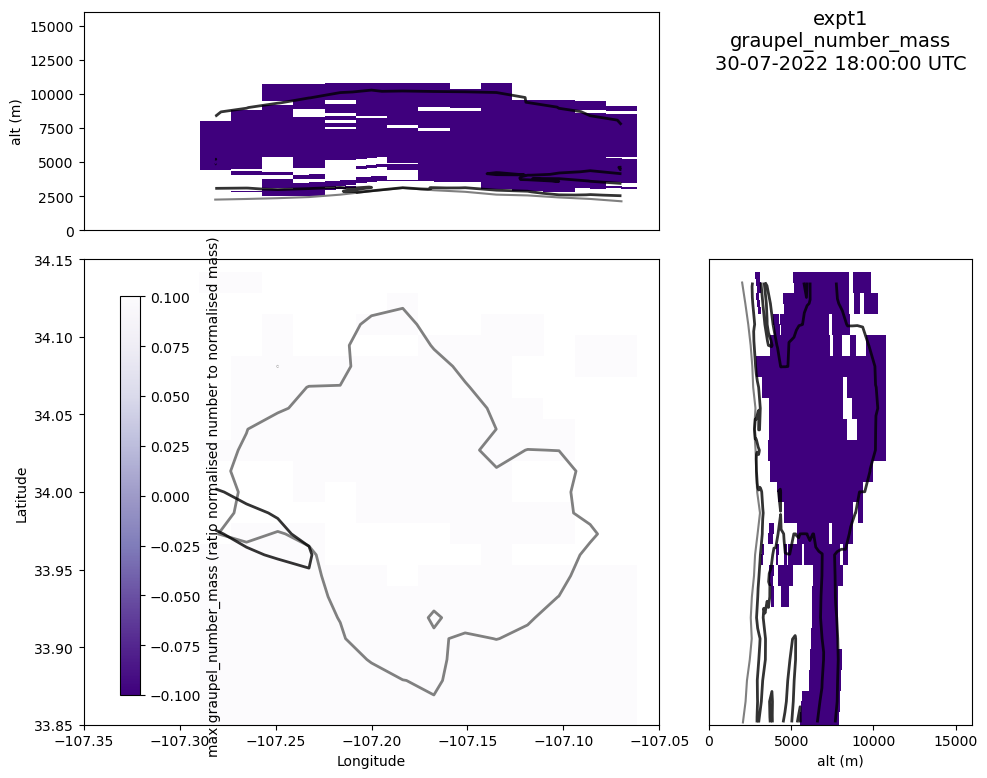

In [100]:
t = '2022-07-30T18:00:00.000000000'

if variable_1_vmax is None:
    vmax_n = sliced_domain[variable_1].max().values
else:
    vmax_n = variable_1_vmax
#vmin_n = sliced_domain[variable_1].min().values
vmin_n = 0 #sliced_domain[variable_1].min().values

a_time = sliced_domain.sel(time=t)
'''

if variable_1_vmax is None:
    vmax_n = sliced_domain_2[variable_1].max().values
else:
    vmax_n = variable_1_vmax
vmin_n = sliced_domain_2[variable_1].min().values

a_time = sliced_domain_2.sel(time=t)
'''
fig = plt.figure(figsize=(10, 8))

# Create a 3x3 logical grid
gs = fig.add_gridspec(3, 3)

# Subplots with custom spans:
ax1 = fig.add_subplot(gs[0, 0:2])   # top-left → 2 cols × 1 row
ax2 = fig.add_subplot(gs[0, 2])     # top-right → 1 col × 1 row
ax2.axis("off")
ax3 = fig.add_subplot(gs[1:3, 0:2]) # bottom-left → 2 cols × 2 rows
ax4 = fig.add_subplot(gs[1:3, 2])   # bottom-right → 1 col × 2 rows

save_name = f"{pd.to_datetime(str(t)).strftime('%y%m%d_%H%M%S')}_{variable_1}"
non_time_save_name = f'{variable_1}'

easy_plotting_lat_lon_map(a_time) # orography
easy_plotting_lat_lon_map(a_time, variable_name=variable_1, a_vmin=vmin_n, a_vmax=vmax_n, specific_colourmap=variable_1_colour, max_alt=plt_max_alt)

cloud_outline_lat_lon_map(a_time, max_alt=plt_max_alt, specific_colourmap=['black'])
'''
if variable_2 is not None:
    ledg_handles = easy_plotting_lat_lon_map(a_time, variable_name=variable_2, colourmesh_contour='contour', contour_level= variable_2_contour_levels , specific_colourmap=variable_2_colours, max_alt=plt_max_alt)
    save_name += f"_{variable_2}_contour"
    non_time_save_name += f"_{variable_2}_contour"


if variable_3 is not None:
    ledg_handles = easy_plotting_lat_lon_map(a_time, variable_name=variable_3, colourmesh_contour='contour', contour_level= variable_3_contour_levels , specific_colourmap=variable_3_colours, multi_contour = ledg_handles, max_alt=plt_max_alt)
    save_name += f"_{variable_3}_contour"
    non_time_save_name += f"_{variable_3}_contour"
'''
## set time 
time_name = pd.to_datetime(str(t)).strftime("%d-%m-%Y %H:%M:%S")
title_str = f'{a_experiment}\n{variable_1}\n{time_name} UTC'
ax2.set_title(title_str, loc="center", y=0.7, fontsize=14)
plt.tight_layout()


In [96]:
sliced_domain['graupel_number_mass_2'].max().values

/home/users/esree/miniforge3/envs/vs_code_envi/lib/python3.13/site-packages/dask/_task_spec.py:759: RuntimeWarning: divide by zero encountered in divide
  return self.func(*new_argspec)
/home/users/esree/miniforge3/envs/vs_code_envi/lib/python3.13/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/home/users/esree/miniforge3/envs/vs_code_envi/lib/python3.13/site-packages/dask/_task_spec.py:759: RuntimeWarning: divide by zero encountered in divide
  return self.func(*new_argspec)
/home/users/esree/miniforge3/envs/vs_code_envi/lib/python3.13/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/home/users/esree/miniforge3/envs/vs_code_envi/lib/python3.13/site-packages/dask/_task_spec.py:759: RuntimeWarning: divide by zero encountered in divide
  return self.func(*new_argspec)
/home/users/esree/miniforge3/envs/vs_code_envi/lib/python3.13/site-packa

array(5.849941e+12, dtype=float32)

In [12]:
save_name = f"{pd.to_datetime(str(t)).strftime('%y%m%d_%H%M%S')}_{variable_1}"
cloud_outline = True # whether to plot the cloud outline - using a contour of total cloud mass (does not include rain!), with a threshold of 1e-6 kg/kg
cloud_mass_threshold = 1e-4 # kg/kg - this is the threshold for the cloud outline contour - from declans paper (https://acp.copernicus.org/articles/25/10907/2025/) - but go a bit lower

save_name += f"_{str(cloud_mass_threshold)[2:]}"


In [13]:
save_name

'220730_180000_cloud_droplets_number_cc_0001'

In [57]:
lon_1d = a_time["lon"].mean(dim="grid_latitude") #(grid_longitude,)
lat_1d = a_time["lat"].mean(dim="grid_longitude") #(grid_latitude,)


lat_max = a_time[variable_1].max(dim="grid_latitude") # (model_level_number, grid_longitude)
z_lat_max = a_time["true_level_height_asl"].max(dim="grid_latitude") # (model_level_number, grid_longitude)

lon_max = a_time[variable_1].max(dim="grid_longitude") # (model_level_number, grid_latitude)
z_lon_max = a_time["true_level_height_asl"].max(dim="grid_longitude") # (model_level_number, grid_latitude)

z_max = a_time[variable_1].max(dim="model_level_number") # (grid_latitude, grid_longitude)

lon_2d = np.tile(lon_1d.values,(lat_max.shape[0], 1))
lat_2d = np.tile(lat_1d.values,(lon_max.shape[0], 1)).T


In [63]:
lon_max.max().values

/home/users/esree/miniforge3/envs/vs_code_envi/lib/python3.13/site-packages/dask/_task_spec.py:759: RuntimeWarning: divide by zero encountered in divide
  return self.func(*new_argspec)
/home/users/esree/miniforge3/envs/vs_code_envi/lib/python3.13/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/home/users/esree/miniforge3/envs/vs_code_envi/lib/python3.13/site-packages/dask/_task_spec.py:759: RuntimeWarning: divide by zero encountered in divide
  return self.func(*new_argspec)
/home/users/esree/miniforge3/envs/vs_code_envi/lib/python3.13/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/home/users/esree/miniforge3/envs/vs_code_envi/lib/python3.13/site-packages/dask/_task_spec.py:759: RuntimeWarning: divide by zero encountered in divide
  return self.func(*new_argspec)
/home/users/esree/miniforge3/envs/vs_code_envi/lib/python3.13/site-packa

array(inf, dtype=float32)

In [65]:
a_time[variable_1].min().values

/home/users/esree/miniforge3/envs/vs_code_envi/lib/python3.13/site-packages/dask/_task_spec.py:759: RuntimeWarning: divide by zero encountered in divide
  return self.func(*new_argspec)
/home/users/esree/miniforge3/envs/vs_code_envi/lib/python3.13/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/home/users/esree/miniforge3/envs/vs_code_envi/lib/python3.13/site-packages/dask/_task_spec.py:759: RuntimeWarning: divide by zero encountered in divide
  return self.func(*new_argspec)
/home/users/esree/miniforge3/envs/vs_code_envi/lib/python3.13/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/home/users/esree/miniforge3/envs/vs_code_envi/lib/python3.13/site-packages/dask/_task_spec.py:759: RuntimeWarning: divide by zero encountered in divide
  return self.func(*new_argspec)
/home/users/esree/miniforge3/envs/vs_code_envi/lib/python3.13/site-packa

array(0., dtype=float32)